# 🚗 AutoWorth AI — Used Car Price & Deal Advisor

**Goal:** predict the fair market price of a used UK car, then compare it to
a seller's asking price to produce a Deal Rating.

**Dataset:** 100,000 UK Used Car Dataset (Kaggle) — 9 manufacturers.
Target: `price` (regression).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [ ]:
import pandas as pd
import numpy as np

files = {
    "Audi": "/content/audi.csv",
    "BMW": "/content/bmw.csv",
    "Ford": "/content/ford.csv",
    "Hyundai": "/content/hyundi.csv",
    "Mercedes": "/content/merc.csv",
    "Skoda": "/content/skoda.csv",
    "Toyota": "/content/toyota.csv",
    "Vauxhall": "/content/vauxhall.csv",
    "Volkswagen": "/content/vw.csv",
}

dataframes = {}
for make, filename in files.items():
    dataframes[make] = pd.read_csv(filename)


In [ ]:
for make, df in dataframes.items():
    print("=" * 50)
    print(f"MAKE: {make}")
    print("=" * 50)

    print("Shape:", df.shape)   # should be 9 columns for every file
    print("\nColumns:", list(df.columns))  #catches column name mismatches
    print("\nData types:\n", df.dtypes)    #price, mileage, year must be numeric , not object
    print("\nMissing values:\n", df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nUnique models:", df["model"].nunique())
    print()

MAKE: Audi
Shape: (10668, 9)

Columns: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']

Data types:
 model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

Missing values:
 model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Duplicate rows: 103

Unique models: 26

MAKE: BMW
Shape: (10781, 9)

Columns: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']

Data types:
 model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

Missing valu

In [ ]:
dataframes["Hyundai"] = dataframes["Hyundai"].rename(columns={"tax(£)": "tax"})

print(dataframes["Hyundai"].columns.tolist())

['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']


In [ ]:
# add a "Make" column to each dataframe, using the key from our files dictionary
for make, df in dataframes.items():
    df["Make"] = make

# quick check on one dataframe
dataframes["Audi"].head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,Audi


In [ ]:
# verify the Make column exists and has exactly one unique value per dataframe
for make, df in dataframes.items():
    print(make, "->", df["Make"].unique(), "| shape:", df.shape)

Audi -> ['Audi'] | shape: (10668, 10)
BMW -> ['BMW'] | shape: (10781, 10)
Ford -> ['Ford'] | shape: (17965, 10)
Hyundai -> ['Hyundai'] | shape: (4860, 10)
Mercedes -> ['Mercedes'] | shape: (13119, 10)
Skoda -> ['Skoda'] | shape: (6267, 10)
Toyota -> ['Toyota'] | shape: (6738, 10)
Vauxhall -> ['Vauxhall'] | shape: (13632, 10)
Volkswagen -> ['Volkswagen'] | shape: (15157, 10)


In [ ]:
# load the two model-specific files
cclass = pd.read_csv("/content/cclass.csv")
focus = pd.read_csv("/content/focus.csv")

shared_cols = ["model", "year", "price", "transmission", "mileage", "fuelType", "engineSize"]

# --- Mercedes / C Class ---
merc_c_class = (
    dataframes["Mercedes"]
    .loc[dataframes["Mercedes"]["model"].str.strip() == "C Class", shared_cols]
    .drop_duplicates()
)

# drop internal duplicates in cclass.csv FIRST, so a repeated ad isn't counted as "new" multiple times
cclass_unique = cclass.drop_duplicates(subset=shared_cols)

merged_cc = cclass_unique.merge(merc_c_class, on=shared_cols, how="left", indicator=True)
new_cclass_rows = merged_cc[merged_cc["_merge"] == "left_only"].drop(columns="_merge").copy()

# --- Ford / Focus ---
ford_focus = (
    dataframes["Ford"]
    .loc[dataframes["Ford"]["model"].str.strip() == "Focus", shared_cols]
    .drop_duplicates()
)

focus_unique = focus.drop_duplicates(subset=shared_cols)

merged_focus = focus_unique.merge(ford_focus, on=shared_cols, how="left", indicator=True)
new_focus_rows = merged_focus[merged_focus["_merge"] == "left_only"].drop(columns="_merge").copy()

print("New rows found in cclass.csv:", new_cclass_rows.shape[0])
print("New rows found in focus.csv:", new_focus_rows.shape[0])

New rows found in cclass.csv: 264
New rows found in focus.csv: 434


In [ ]:
# these files never had tax/mpg columns — mark them explicitly as missing
new_cclass_rows["tax"] = np.nan
new_cclass_rows["mpg"] = np.nan
new_cclass_rows["Make"] = "Mercedes"

new_focus_rows["tax"] = np.nan
new_focus_rows["mpg"] = np.nan
new_focus_rows["Make"] = "Ford"

print(new_cclass_rows.shape)
print(new_focus_rows.shape)

(264, 10)
(434, 10)


In [ ]:
# combine all 9 main manufacturer dataframes into a list
all_pieces = list(dataframes.values())

# add the two "new rows only" pieces from cclass.csv / focus.csv
all_pieces.append(new_cclass_rows)
all_pieces.append(new_focus_rows)

car_data = pd.concat(all_pieces, ignore_index=True)

print("Final shape:", car_data.shape)

Final shape: (99885, 10)


In [ ]:
print("Shape:", car_data.shape)
print("\nColumns:", list(car_data.columns))
print("\nMake counts:\n", car_data["Make"].value_counts())
print("\nMissing values:\n", car_data.isnull().sum())

Shape: (99885, 10)

Columns: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'Make']

Make counts:
 Make
Ford          18399
Volkswagen    15157
Vauxhall      13632
Mercedes      13383
BMW           10781
Audi          10668
Toyota         6738
Skoda          6267
Hyundai        4860
Name: count, dtype: int64

Missing values:
 model             0
year              0
price             0
transmission      0
mileage           0
fuelType          0
tax             698
mpg             698
engineSize        0
Make              0
dtype: int64


In [ ]:
print(car_data[["price", "year", "mileage", "engineSize", "mpg", "tax"]].describe())

               price          year        mileage    engineSize           mpg  \
count   99885.000000  99885.000000   99885.000000  99885.000000  99187.000000   
mean    16808.770506   2017.084667   23086.300105      1.663493     55.166825   
std      9861.683184      2.137056   21205.573906      0.557935     16.138522   
min       450.000000   1970.000000       1.000000      0.000000      0.300000   
25%     10000.000000   2016.000000    7439.000000      1.200000     47.100000   
50%     14495.000000   2017.000000   17452.000000      1.600000     54.300000   
75%     20850.000000   2019.000000   32363.000000      2.000000     62.800000   
max    159999.000000   2060.000000  323000.000000      6.600000    470.800000   

                tax  
count  99187.000000  
mean     120.299838  
std       63.150926  
min        0.000000  
25%      125.000000  
50%      145.000000  
75%      145.000000  
max      580.000000  


In [ ]:
# investigate suspicious years
print("Cars with year > 2026 (impossible — future car):")
print(car_data[car_data["year"] > 2026][["Make", "model", "year", "price"]])

print("\nCars with year < 1990 (rare but check if real):")
print(car_data[car_data["year"] < 1990][["Make", "model", "year", "price"]])

Cars with year > 2026 (impossible — future car):
       Make    model  year  price
39175  Ford   Fiesta  2060   6495

Cars with year < 1990 (rare but check if real):
           Make     model  year  price
56346  Mercedes   M Class  1970  24999
81235  Vauxhall    Zafira  1970  10495


In [ ]:
# document the decision before acting: these 3 rows are logically impossible
# given the model's real launch date or being a future year — not just "unusual"
before_shape = car_data.shape[0]

invalid_year_mask = (
    (car_data["year"] > 2026) |                                    # impossible: future car
    ((car_data["model"].str.strip() == "Zafira") & (car_data["year"] < 1999)) |   # Zafira launched 1999
    ((car_data["model"].str.strip() == "M Class") & (car_data["year"] < 1997))    # M Class launched ~1997
)

print("Rows to be removed:", invalid_year_mask.sum())
print(car_data[invalid_year_mask][["Make", "model", "year", "price"]])

car_data = car_data[~invalid_year_mask].copy()

print("\nShape before:", before_shape, "-> Shape after:", car_data.shape[0])

Rows to be removed: 3
           Make     model  year  price
39175      Ford    Fiesta  2060   6495
56346  Mercedes   M Class  1970  24999
81235  Vauxhall    Zafira  1970  10495

Shape before: 99885 -> Shape after: 99882


In [ ]:
# investigate engineSize = 0 rows
zero_engine = car_data[car_data["engineSize"] == 0]

print("Total rows with engineSize = 0:", len(zero_engine))
print("\nFuel type breakdown for these rows:")
print(zero_engine["fuelType"].value_counts())

print("\nSample of non-Electric rows with engineSize = 0:")
print(zero_engine[zero_engine["fuelType"] != "Electric"][["Make", "model", "year", "fuelType", "engineSize", "price"]].head(15))

Total rows with engineSize = 0: 275

Fuel type breakdown for these rows:
fuelType
Petrol      165
Diesel       69
Hybrid       38
Electric      2
Other         1
Name: count, dtype: int64

Sample of non-Electric rows with engineSize = 0:
      Make model  year fuelType  engineSize  price
7505  Audi    Q5  2019   Petrol         0.0  44790
7506  Audi    Q3  2019   Diesel         0.0  32788
7516  Audi    Q3  2020   Petrol         0.0  29944
7517  Audi    Q3  2020   Diesel         0.0  33333
7518  Audi    Q3  2020   Petrol         0.0  29944
7519  Audi    Q3  2020   Petrol         0.0  37990
7521  Audi    Q5  2020   Petrol         0.0  49790
7542  Audi    Q3  2019   Petrol         0.0  31888
7545  Audi    Q2  2020   Petrol         0.0  24988
7546  Audi    A3  2017   Petrol         0.0  17390
7591  Audi    Q5  2019   Diesel         0.0  33390
7598  Audi    A3  2019   Petrol         0.0  22000
7611  Audi    Q3  2020   Petrol         0.0  32444
7625  Audi    A3  2019   Petrol         0.0  234

In [ ]:
mask_fake_zero = (car_data["engineSize"] == 0) & (car_data["fuelType"] != "Electric")
print("Rows to fix (non-Electric, engineSize=0):", mask_fake_zero.sum())

car_data.loc[mask_fake_zero, "engineSize"] = np.nan
car_data["engineSize"] = car_data.groupby(["Make", "model"])["engineSize"].transform(lambda x: x.fillna(x.median()))

car_data["engineSize"] = car_data.groupby(["Make", "model"])["engineSize"].transform( lambda x: x.fillna(x.median()))

Rows to fix (non-Electric, engineSize=0): 273


In [ ]:
print("Current rows with engineSize = 0:", (car_data["engineSize"] == 0).sum())
print("Current missing (NaN) engineSize:", car_data["engineSize"].isnull().sum())
print("\nengineSize describe:")
print(car_data["engineSize"].describe())

Current rows with engineSize = 0: 2
Current missing (NaN) engineSize: 1

engineSize describe:
count    99881.000000
mean         1.667473
std          0.551877
min          0.000000
25%          1.200000
50%          1.600000
75%          2.000000
max          6.600000
Name: engineSize, dtype: float64


In [ ]:
print(car_data[car_data["engineSize"].isnull()][["Make", "model", "year", "fuelType", "price"]])

           Make model  year fuelType  price
55621  Mercedes   230  2007   Petrol   4500


In [ ]:
# for the one row still missing (rare model with no sibling rows), fall back to the Make-level median
mercedes_median_engine = car_data.loc[car_data["Make"] == "Mercedes", "engineSize"].median()

print("Mercedes median engineSize:", mercedes_median_engine)

car_data["engineSize"] = car_data["engineSize"].fillna(mercedes_median_engine)

# final check: no missing values left anywhere
print("Remaining missing engineSize:", car_data["engineSize"].isnull().sum())

Mercedes median engineSize: 2.0
Remaining missing engineSize: 0


In [ ]:
# investigate unrealistically high mpg values
print("Cars with mpg > 100 (very high, worth checking):")
print(car_data[car_data["mpg"] > 100][["Make", "model", "year", "fuelType", "mpg", "engineSize"]].sort_values("mpg", ascending=False).head(20))

print("\nHow many rows have mpg > 100?", (car_data["mpg"] > 100).sum())

# also check the low end — an unrealistically low mpg
print("\nCars with mpg < 15 (very low, worth checking):")
print(car_data[car_data["mpg"] < 15][["Make", "model", "year", "fuelType", "mpg", "engineSize"]].sort_values("mpg").head(20))
print("\nHow many rows have mpg < 15?", (car_data["mpg"] < 15).sum())

Cars with mpg > 100 (very high, worth checking):
      Make model  year fuelType    mpg  engineSize
11446  BMW    i3  2017   Hybrid  470.8         0.6
12534  BMW    i3  2017   Hybrid  470.8         0.6
10700  BMW    i3  2016    Other  470.8         0.6
11448  BMW    i3  2017   Hybrid  470.8         0.6
11289  BMW    i3  2017   Hybrid  470.8         0.6
14768  BMW    i3  2017   Hybrid  470.8         0.6
14296  BMW    i3  2015   Hybrid  470.8         0.6
14777  BMW    i3  2015   Hybrid  470.8         0.6
14581  BMW    i3  2017   Hybrid  470.8         0.6
13945  BMW    i3  2016   Hybrid  470.8         0.6
14879  BMW    i3  2015   Hybrid  470.8         0.6
16413  BMW    i3  2017   Hybrid  470.8         0.6
15417  BMW    i3  2014   Hybrid  470.8         0.6
15534  BMW    i3  2014   Hybrid  470.8         0.6
15844  BMW    i3  2017   Hybrid  470.8         0.6
13020  BMW    i3  2016   Hybrid  470.8         0.6
16288  BMW    i3  2017   Hybrid  470.8         0.6
16170  BMW    i3  2017   Hybrid  

In [ ]:
# realistic mpg values are always well above 10; treat lower values as data errors
mask_low_mpg = (car_data["mpg"] < 15) & (car_data["mpg"].notnull())

print("Rows to fix (unrealistically low mpg):", mask_low_mpg.sum())

car_data.loc[mask_low_mpg, "mpg"] = np.nan

car_data["mpg"] = car_data.groupby(["Make", "model", "fuelType"])["mpg"].transform(
    lambda x: x.fillna(x.median())
)

print("Remaining missing mpg:", car_data["mpg"].isnull().sum())

Rows to fix (unrealistically low mpg): 35
Remaining missing mpg: 10


In [ ]:
print(car_data[car_data["mpg"].isnull()][["Make", "model", "year", "fuelType", "price"]])

           Make     model  year fuelType  price
11905       BMW        X3  2020   Hybrid  52910
12784       BMW        X3  2020   Hybrid  54990
16800       BMW        X3  2020   Hybrid  47000
16840       BMW        X3  2020   Hybrid  42990
16866       BMW        X3  2020   Hybrid  53995
17633       BMW        X3  2020   Hybrid  52991
46798  Mercedes   A Class  2020   Hybrid  30231
46834  Mercedes   A Class  2020   Hybrid  30231
51244  Mercedes   A Class  2020   Hybrid  31500
54640  Mercedes   A Class  2020   Hybrid  33900


In [ ]:
# these rows had NO surviving sibling at the Make+model+fuelType level, so widen to Make+fuelType
mask_still_missing = car_data["mpg"].isnull()

car_data["mpg"] = car_data.groupby(["Make", "fuelType"])["mpg"].transform(
    lambda x: x.fillna(x.median())
)

print("Remaining missing mpg after widening the group:", car_data["mpg"].isnull().sum())

Remaining missing mpg after widening the group: 0


In [ ]:
print("Missing values summary:\n")
print(car_data.isnull().sum())
print("\nengineSize describe:\n", car_data["engineSize"].describe())
print("\nmpg describe:\n", car_data["mpg"].describe())

Missing values summary:

model             0
year              0
price             0
transmission      0
mileage           0
fuelType          0
tax             698
mpg               0
engineSize        0
Make              0
dtype: int64

engineSize describe:
 count    99882.000000
mean         1.667477
std          0.551875
min          0.000000
25%          1.200000
50%          1.600000
75%          2.000000
max          6.600000
Name: engineSize, dtype: float64

mpg describe:
 count    99882.000000
mean        55.266667
std         16.173572
min         17.800000
25%         47.100000
50%         54.300000
75%         62.800000
max        470.800000
Name: mpg, dtype: float64


In [ ]:
missing_tax = car_data[car_data["tax"].isnull()]
print("Total missing tax rows:", len(missing_tax))
print("\nBreakdown by Make and model:")
print(missing_tax.groupby(["Make", "model"]).size())

Total missing tax rows: 698

Breakdown by Make and model:
Make      model  
Ford      Focus      434
Mercedes  C Class    264
dtype: int64


In [ ]:
car_data["tax"] = car_data.groupby(["Make", "model"])["tax"].transform(
    lambda x: x.fillna(x.median())
)

print("Remaining missing tax after Make+model median fill:", car_data["tax"].isnull().sum())

Remaining missing tax after Make+model median fill: 0


In [ ]:
print("Final missing values check across all columns:\n")
print(car_data.isnull().sum())
print("\nFinal shape:", car_data.shape)

Final missing values check across all columns:

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

Final shape: (99882, 10)


In [ ]:

print("Total duplicate rows in the combined dataset:", car_data.duplicated().sum())

# look at a sample of duplicated rows to understand what they look like
duplicated_rows = car_data[car_data.duplicated(keep=False)].sort_values(by=list(car_data.columns))
print("\nSample of duplicate rows:")
print(duplicated_rows.head(20))

Total duplicate rows in the combined dataset: 1478

Sample of duplicate rows:
           model  year  price transmission  mileage fuelType    tax   mpg  \
18275   1 Series  2015   8490       Manual    50000   Petrol  125.0  50.4   
18451   1 Series  2015   8490       Manual    50000   Petrol  125.0  50.4   
15874   1 Series  2016  14652       Manual     9461   Diesel   20.0  70.6   
16285   1 Series  2016  14652       Manual     9461   Diesel   20.0  70.6   
13352   1 Series  2016  20990       Manual       10   Diesel   20.0  68.9   
13388   1 Series  2016  20990       Manual       10   Diesel   20.0  68.9   
13002   1 Series  2017  14397       Manual     9243   Petrol  145.0  52.3   
14338   1 Series  2017  14397       Manual     9243   Petrol  145.0  52.3   
11840   1 Series  2017  20995    Semi-Auto    31544   Petrol  145.0  39.8   
11841   1 Series  2017  20995    Semi-Auto    31544   Petrol  145.0  39.8   
11311   1 Series  2019  21898       Manual     4100   Petrol  150.0  41.5  

In [ ]:
before = car_data.shape[0]

car_data = car_data.drop_duplicates().reset_index(drop=True)

after = car_data.shape[0]
print(f"Rows before: {before} -> Rows after: {after} (removed {before - after} duplicate rows)")

Rows before: 99882 -> Rows after: 98404 (removed 1478 duplicate rows)


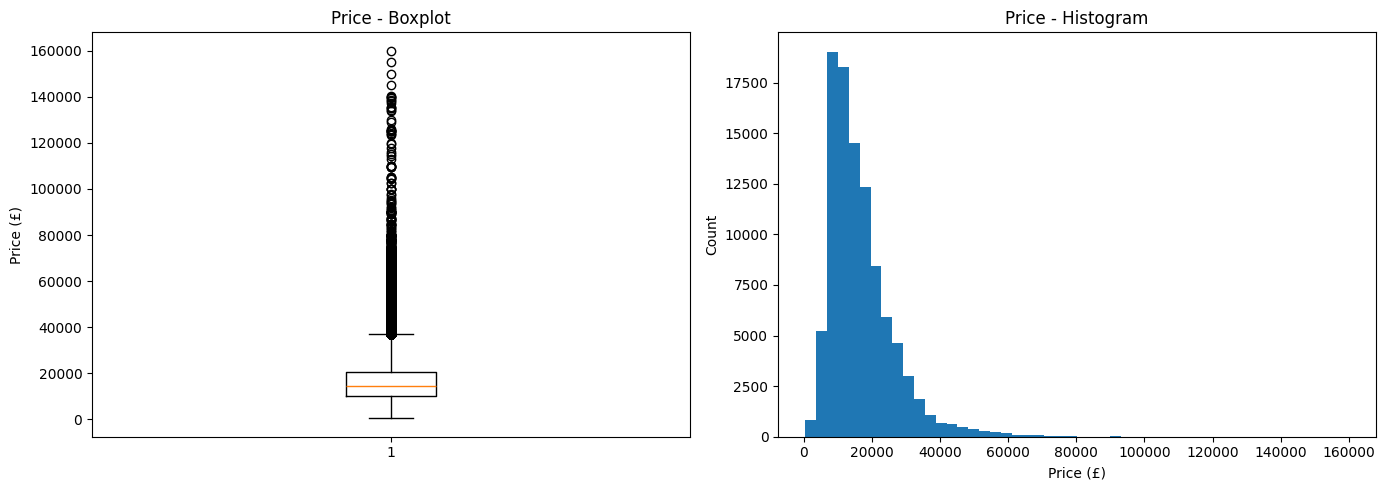

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(car_data["price"])
axes[0].set_title("Price - Boxplot")
axes[0].set_ylabel("Price (£)")

axes[1].hist(car_data["price"], bins=50)
axes[1].set_title("Price - Histogram")
axes[1].set_xlabel("Price (£)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
Q1 = car_data["price"].quantile(0.25)
Q3 = car_data["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

outliers_high = car_data[car_data["price"] > upper_bound]
outliers_low = car_data[car_data["price"] < lower_bound]

print(f"\nRows above upper bound: {len(outliers_high)}")
print(f"Rows below lower bound: {len(outliers_low)}")

print("\nSample of expensive outliers:")
print(outliers_high[["Make", "model", "year", "price"]].sort_values("price", ascending=False).head(15))

Q1: 9999.0, Q3: 20750.0, IQR: 10751.0
Lower bound: -6127.5, Upper bound: 36876.5

Rows above upper bound: 3850
Rows below lower bound: 0

Sample of expensive outliers:
           Make      model  year   price
49913  Mercedes    G Class  2020  159999
53609  Mercedes    G Class  2020  154998
43815  Mercedes   SL CLASS  2011  149948
4743       Audi         R8  2020  145000
52353  Mercedes    A Class  2019  140319
50099  Mercedes    G Class  2018  139995
43818  Mercedes    G Class  2019  139948
52721  Mercedes    A Class  2019  139559
52431  Mercedes    A Class  2020  138439
2242       Audi         R8  2020  137995
4155       Audi         R8  2019  137500
49617  Mercedes    G Class  2018  135771
51527  Mercedes    G Class  2018  135124
3350       Audi         R8  2019  135000
52289  Mercedes    A Class  2019  134219


In [ ]:
a_class_expensive = car_data[(car_data["model"].str.strip() == "A Class") & (car_data["price"] > 100000)]
print("Suspiciously expensive A Class rows:", len(a_class_expensive))
print(a_class_expensive[["Make", "model", "year", "price", "mileage", "engineSize", "fuelType", "transmission"]])

Suspiciously expensive A Class rows: 17
           Make     model  year   price  mileage  engineSize fuelType  \
44819  Mercedes   A Class  2019  104999     5822         4.0   Petrol   
46428  Mercedes   A Class  2019  123846     2951         4.0   Petrol   
46446  Mercedes   A Class  2019  125796      637         4.0   Petrol   
47855  Mercedes   A Class  2019  124366      880         4.0   Petrol   
48513  Mercedes   A Class  2019  126000      250         4.0   Petrol   
49035  Mercedes   A Class  2019  105000     6807         4.0   Petrol   
49924  Mercedes   A Class  2019  129990     1000         4.0   Petrol   
50823  Mercedes   A Class  2019  115359     1000         4.0   Petrol   
51491  Mercedes   A Class  2019  109445      195         4.0   Petrol   
52289  Mercedes   A Class  2019  134219     1000         4.0   Petrol   
52353  Mercedes   A Class  2019  140319      785         4.0   Petrol   
52361  Mercedes   A Class  2018  109989     2122         4.0   Petrol   
52431  Merc

In [ ]:
# these rows are actually AMG performance variants mislabeled under the base "A Class" name
# identified by an engine size (4.0L) far outside A Class's normal range
amg_mask = (car_data["model"].str.strip() == "A Class") & (car_data["engineSize"] == 4.0)

print("Rows to relabel as AMG:", amg_mask.sum())

car_data.loc[amg_mask, "model"] = "A Class AMG"

# verify
print(car_data[car_data["model"] == "A Class AMG"][["Make","model","price","engineSize"]].describe())

Rows to relabel as AMG: 32
               price  engineSize
count      32.000000        32.0
mean   102074.968750         4.0
std     23726.752972         0.0
min     57950.000000         4.0
25%     80092.750000         4.0
50%    102561.500000         4.0
75%    123976.000000         4.0
max    140319.000000         4.0


In [ ]:
# recompute after the AMG relabel
Q1 = car_data["price"].quantile(0.25)
Q3 = car_data["price"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers_high = car_data[car_data["price"] > upper_bound]
print("Remaining high-price outliers:", len(outliers_high))

# which makes/models dominate the outliers? this tells us if it's "expensive brands" (legit)
# vs scattered noise (suspicious)
print("\nTop Make+model combos among outliers:")
print(outliers_high.groupby(["Make", "model"]).size().sort_values(ascending=False).head(15))

Remaining high-price outliers: 3850

Top Make+model combos among outliers:
Make        model    
Mercedes    E Class      284
Audi        Q7           282
BMW         X5           263
Mercedes    C Class      235
            GLE Class    232
            GLC Class    228
Audi        Q5           195
Volkswagen  Touareg      163
Mercedes    S Class      117
BMW         X3            92
            3 Series      85
Mercedes    V Class       84
BMW         M4            83
            X4            74
Volkswagen  Caravelle     72
dtype: int64


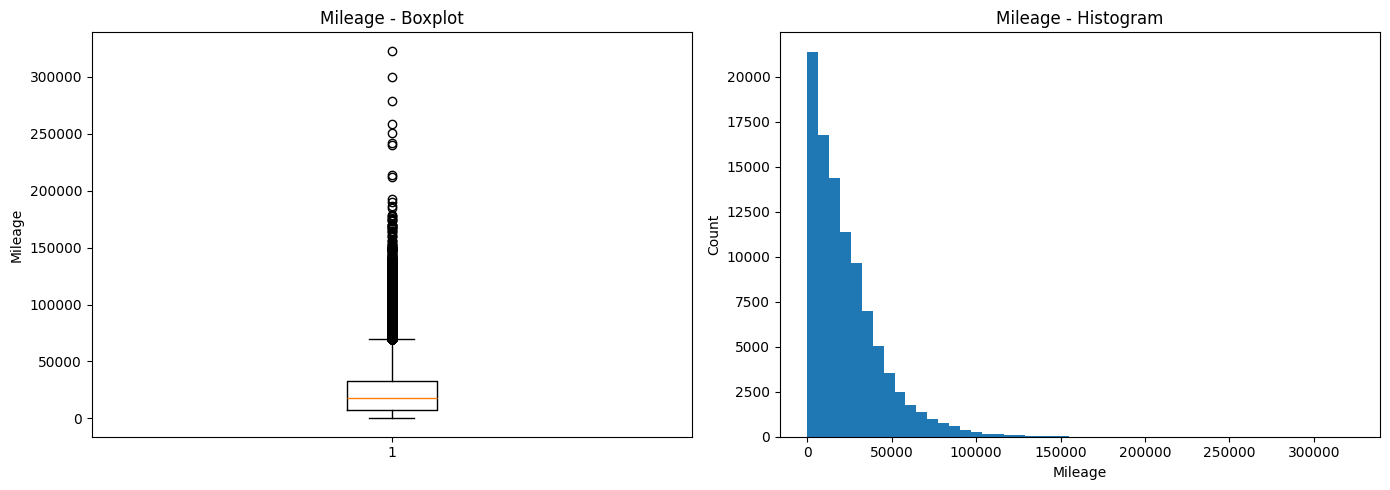

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(car_data["mileage"])
axes[0].set_title("Mileage - Boxplot")
axes[0].set_ylabel("Mileage")

axes[1].hist(car_data["mileage"], bins=50)
axes[1].set_title("Mileage - Histogram")
axes[1].set_xlabel("Mileage")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
Q1 = car_data["mileage"].quantile(0.25)
Q3 = car_data["mileage"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

outliers_high = car_data[car_data["mileage"] > upper_bound]
outliers_low = car_data[car_data["mileage"] < lower_bound]

print(f"\nRows above upper bound: {len(outliers_high)}")
print(f"Rows below lower bound: {len(outliers_low)}")

print("\nSample of highest-mileage rows:")
print(car_data.sort_values("mileage", ascending=False)[["Make", "model", "year", "mileage", "price"]].head(15))

Q1: 7678.75, Q3: 32512.0, IQR: 24833.25
Lower bound: -29571.125, Upper bound: 69761.875

Rows above upper bound: 3887
Rows below lower bound: 0

Sample of highest-mileage rows:
             Make       model  year  mileage  price
9716         Audi          A6  2008   323000   2490
62659       Skoda     Octavia  2010   300000   1190
80033    Vauxhall      Zafira  2013   279000   1395
54898    Mercedes     V Class  2010   259000   6949
62176       Skoda     Octavia  2010   250650   1485
62682       Skoda     Octavia  2009   241565   2750
56454    Mercedes     A Class  2016   240494  16249
19867         BMW          X5  2012   214000   7250
96067  Volkswagen   Caravelle  2012   212000  11995
87998  Volkswagen        Golf  2009   193000   2250
18762         BMW    3 Series  2011   190000   3493
74768    Vauxhall       Astra  2008   186500   1695
55135    Mercedes         CLK  2003   185000   3495
19862         BMW    5 Series  2013   178987   8999
96058  Volkswagen   Caravelle  2006   17800

In [ ]:
suspicious_row = car_data[(car_data["Make"]=="Mercedes") & (car_data["model"].str.strip()=="A Class") & (car_data["mileage"]==240494)]
print(suspicious_row)

          model  year  price transmission  mileage fuelType   tax   mpg  \
56454   A Class  2016  16249    Automatic   240494   Diesel  20.0  68.9   

       engineSize      Make  
56454         2.1  Mercedes  


In [ ]:
print("Final dataset shape:", car_data.shape)
print("\nMissing values:\n", car_data.isnull().sum())
print("\nDuplicate rows:", car_data.duplicated().sum())
print("\nData types:\n", car_data.dtypes)

Final dataset shape: (98404, 10)

Missing values:
 model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

Duplicate rows: 0

Data types:
 model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax             float64
mpg             float64
engineSize      float64
Make             object
dtype: object


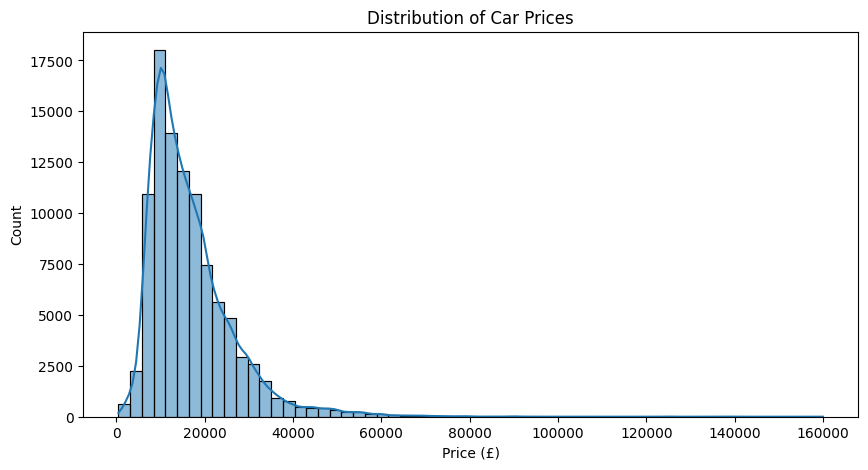

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(car_data["price"], bins=60, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price (£)")
plt.ylabel("Count")
plt.show()

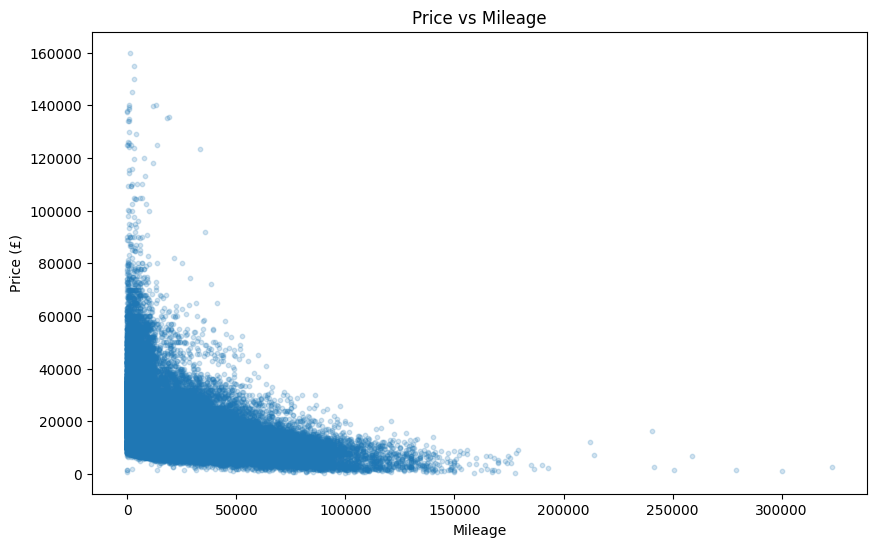

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(car_data["mileage"], car_data["price"], alpha=0.2, s=10)
plt.title("Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price (£)")
plt.show()

In [ ]:
correlation = car_data["mileage"].corr(car_data["price"])
print("Correlation between mileage and price:", correlation)

Correlation between mileage and price: -0.4192078147730401


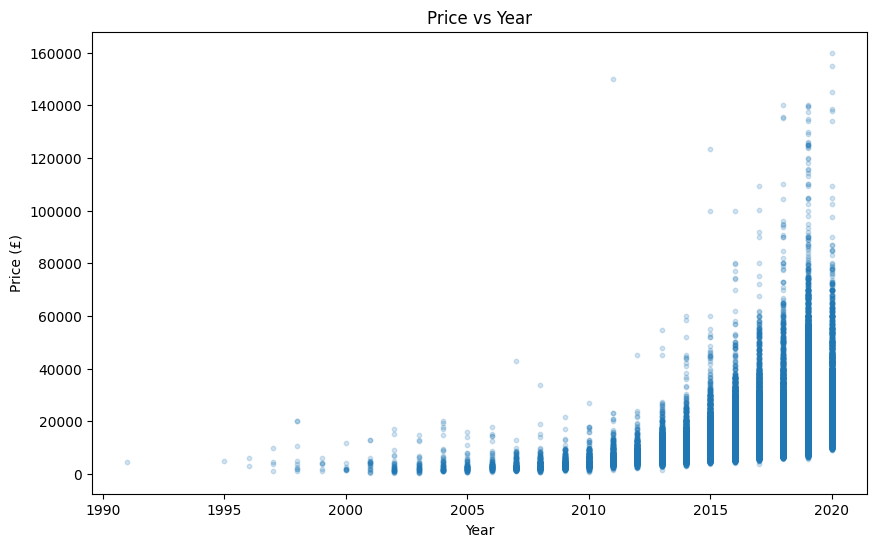

Correlation between year and price: 0.49506591318335785


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(car_data["year"], car_data["price"], alpha=0.2, s=10)
plt.title("Price vs Year")
plt.xlabel("Year")
plt.ylabel("Price (£)")
plt.show()

correlation_year = car_data["year"].corr(car_data["price"])
print("Correlation between year and price:", correlation_year)

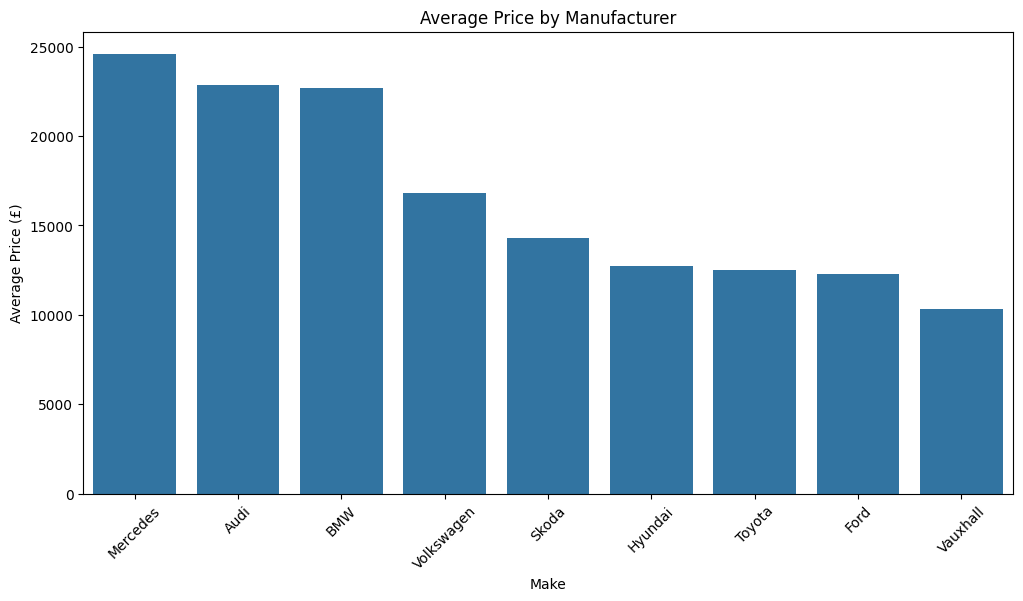

Make
Mercedes      24597.387411
Audi          22850.991100
BMW           22692.888691
Volkswagen    16807.898073
Skoda         14284.802683
Hyundai       12727.809384
Toyota        12529.799074
Ford          12311.472046
Vauxhall      10314.245908
Name: price, dtype: float64


In [ ]:
plt.figure(figsize=(12, 6))
avg_price_by_make = car_data.groupby("Make")["price"].mean().sort_values(ascending=False)

sns.barplot(x=avg_price_by_make.index, y=avg_price_by_make.values)
plt.title("Average Price by Manufacturer")
plt.xlabel("Make")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=45)
plt.show()

print(avg_price_by_make)

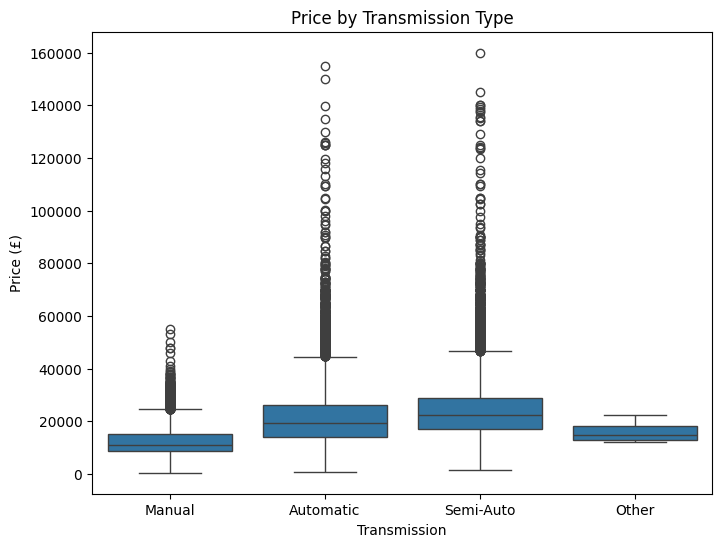

transmission
Automatic    19250.0
Manual       11000.0
Other        14749.0
Semi-Auto    22199.5
Name: price, dtype: float64


In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="transmission", y="price", data=car_data)
plt.title("Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Price (£)")
plt.show()

print(car_data.groupby("transmission")["price"].median())

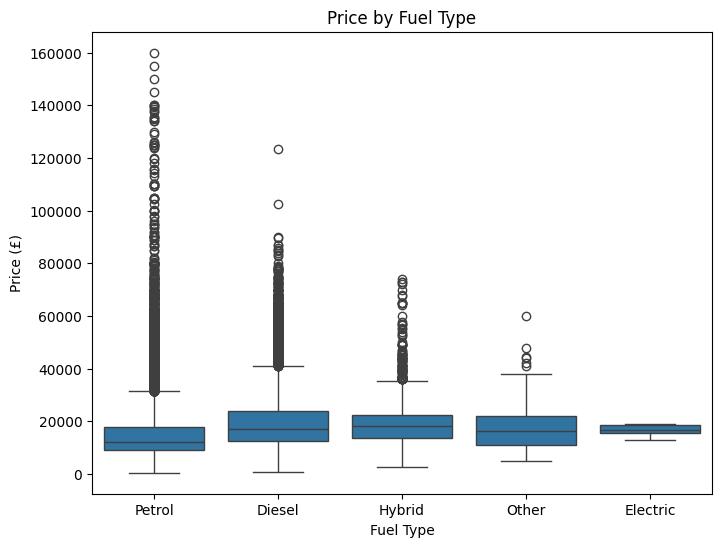

fuelType
Diesel      17000.0
Electric    16687.5
Hybrid      18298.0
Other       16450.0
Petrol      11999.0
Name: price, dtype: float64


In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="fuelType", y="price", data=car_data)
plt.title("Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price (£)")
plt.show()

print(car_data.groupby("fuelType")["price"].median())

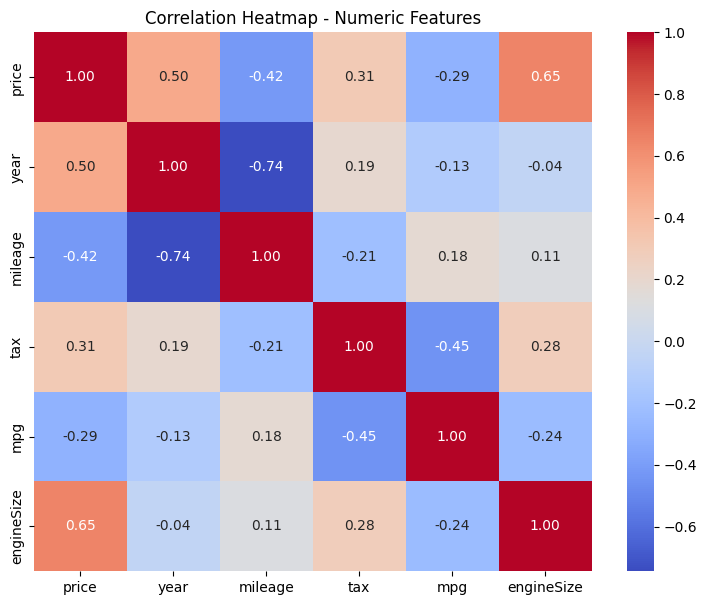

In [ ]:
numeric_cols = ["price", "year", "mileage", "tax", "mpg", "engineSize"]

plt.figure(figsize=(9, 7))
sns.heatmap(car_data[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Numeric Features")
plt.show()

## EDA — Correlation Heatmap

`engineSize` shows the strongest correlation with price (0.65), ahead of
year (0.50) and mileage (-0.42). Notably, year and mileage are strongly
negatively correlated (-0.74) — motivating the Mileage_Per_Year feature
created next.

In [ ]:
print("Latest year in the dataset:", car_data["year"].max())

Latest year in the dataset: 2020


In [ ]:
REFERENCE_YEAR = 2020
car_data["Car_Age"] = REFERENCE_YEAR - car_data["year"]

# sanity check: age should never be negative, and should make sense
print(car_data["Car_Age"].describe())
print("\nAny negative ages?", (car_data["Car_Age"] < 0).sum())

count    98404.000000
mean         2.935653
std          2.121323
min          0.000000
25%          1.000000
50%          3.000000
75%          4.000000
max         29.000000
Name: Car_Age, dtype: float64

Any negative ages? 0


In [ ]:
print(car_data[car_data["Car_Age"] == 29][["Make", "model", "year", "price"]])

           Make     model  year  price
97892  Mercedes   C Class  1991   4450


In [ ]:
invalid_cclass = (car_data["model"].str.strip() == "C Class") & (car_data["year"] < 1993)

print("Rows to remove:", invalid_cclass.sum())
print(car_data[invalid_cclass][["Make", "model", "year", "price"]])

car_data = car_data[~invalid_cclass].copy()

# Car_Age must be recalculated since we removed a row
car_data["Car_Age"] = REFERENCE_YEAR - car_data["year"]

print("\nNew shape:", car_data.shape)
print("Max Car_Age now:", car_data["Car_Age"].max())

Rows to remove: 1
           Make     model  year  price
97892  Mercedes   C Class  1991   4450

New shape: (98403, 11)
Max Car_Age now: 25


In [ ]:
car_data["Mileage_Per_Year"] = car_data["mileage"] / car_data["Car_Age"].replace(0, 1)

print(car_data["Mileage_Per_Year"].describe())

# sanity check: any infinite or NaN values left?
print("\nInfinite values:", np.isinf(car_data["Mileage_Per_Year"]).sum())
print("Missing values:", car_data["Mileage_Per_Year"].isnull().sum())

count     98403.000000
mean       7479.124472
std        4651.747467
min           0.052632
25%        4317.775000
50%        6820.000000
75%        9917.875000
max      132644.000000
Name: Mileage_Per_Year, dtype: float64

Infinite values: 0
Missing values: 0


In [ ]:
print(car_data.sort_values("Mileage_Per_Year", ascending=False)[["Make", "model", "year", "mileage", "Car_Age", "Mileage_Per_Year", "price"]].head(10))

           Make      model  year  mileage  Car_Age  Mileage_Per_Year  price
62459     Skoda    Octavia  2019   132644        1          132644.0  13250
14151       BMW   3 Series  2019    68945        1           68945.0  25780
56454  Mercedes    A Class  2016   240494        4           60123.5  16249
60441     Skoda    Octavia  2019    59434        1           59434.0  10995
24735      Ford       Kuga  2019    53825        1           53825.0  11698
62825     Skoda     Superb  2019    53300        1           53300.0  15980
62838     Skoda     Superb  2019    51900        1           51900.0  13980
62801     Skoda     Superb  2019    51900        1           51900.0  13680
62834     Skoda     Superb  2019    50000        1           50000.0  13980
62839     Skoda     Superb  2019    49900        1           49900.0  13980


In [ ]:
extreme_usage_mask = car_data["Mileage_Per_Year"] > 100000

print("Rows to remove:", extreme_usage_mask.sum())
print(car_data[extreme_usage_mask][["Make", "model", "year", "mileage", "Mileage_Per_Year"]])

car_data = car_data[~extreme_usage_mask].copy()
print("\nNew shape:", car_data.shape)

Rows to remove: 1
        Make     model  year  mileage  Mileage_Per_Year
62459  Skoda   Octavia  2019   132644          132644.0

New shape: (98402, 12)


In [ ]:
print(car_data["engineSize"].describe())
print("\nPercentage of cars with engineSize >= 3.0:", (car_data["engineSize"] >= 3.0).mean() * 100, "%")

print("\nSample of high-performance models:")
print(car_data[car_data["engineSize"] >= 3.0].groupby(["Make", "model"]).size().sort_values(ascending=False).head(10))

count    98402.000000
mean         1.669041
std          0.552825
min          0.000000
25%          1.200000
50%          1.600000
75%          2.000000
max          6.600000
Name: engineSize, dtype: float64

Percentage of cars with engineSize >= 3.0: 6.200077234202557 %

Sample of high-performance models:
Make        model    
BMW         3 Series     479
Mercedes    E Class      437
BMW         X5           425
Audi        Q7           394
Volkswagen  Touareg      347
Mercedes    C Class      284
            GLE Class    260
BMW         4 Series     242
            1 Series     238
            5 Series     228
dtype: int64


In [ ]:
car_data["High_Performance"] = (car_data["engineSize"] >= 3.0).astype(int)

print(car_data["High_Performance"].value_counts())

# quick sanity check: does this flag actually relate to price, as expected?
print("\nAverage price by High_Performance flag:")
print(car_data.groupby("High_Performance")["price"].mean())

High_Performance
0    92301
1     6101
Name: count, dtype: int64

Average price by High_Performance flag:
High_Performance
0    15537.534187
1    35527.541387
Name: price, dtype: float64


## Feature Engineering Summary

Three features created: **Car_Age** (2020 − year), **Mileage_Per_Year**
(mileage ÷ Car_Age, safely handling Car_Age=0), and **High_Performance**
(engineSize ≥ 3.0L, covering 6.2% of the data). High_Performance was
validated with evidence: flagged cars average £35,528 vs £15,537 for others.

In [ ]:
from sklearn.model_selection import train_test_split

# define features (X) and target (y)
X = car_data.drop(columns=["price"])
y = car_data["price"]

# Step 1: split off the test set first (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Step 2: split the remaining 85% into train (70% of total) and validation (15% of total)
# 0.15 / 0.85 ≈ 0.176 -> this gives exactly 15% of the ORIGINAL data as validation
val_ratio = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, random_state=42
)

print("Train size:", X_train.shape[0], f"({X_train.shape[0]/len(X):.1%})")
print("Validation size:", X_val.shape[0], f"({X_val.shape[0]/len(X):.1%})")
print("Test size:", X_test.shape[0], f"({X_test.shape[0]/len(X):.1%})")

Train size: 68880 (70.0%)
Validation size: 14761 (15.0%)
Test size: 14761 (15.0%)


In [ ]:
print("Column data types:\n")
print(X_train.dtypes)

categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Column data types:

model                object
year                  int64
transmission         object
mileage               int64
fuelType             object
tax                 float64
mpg                 float64
engineSize          float64
Make                 object
Car_Age               int64
Mileage_Per_Year    float64
High_Performance      int64
dtype: object

Categorical columns: ['model', 'transmission', 'fuelType', 'Make']
Numerical columns: ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'Car_Age', 'Mileage_Per_Year', 'High_Performance']


In [ ]:
for col in categorical_cols:
    print(f"{col}: {X_train[col].nunique()} unique values")

print("\nModel value counts (top 15):")
print(X_train["model"].value_counts().head(15))

print("\nModel value counts (bottom 15 - rare models):")
print(X_train["model"].value_counts().tail(15))

model: 193 unique values
transmission: 4 unique values
fuelType: 5 unique values
Make: 9 unique values

Model value counts (top 15):
model
Fiesta      4579
Focus       3473
Golf        3349
C Class     2759
Polo        2282
Corsa       2263
Astra       1828
A Class     1696
3 Series    1688
Kuga        1557
Mokka X     1485
Yaris       1472
1 Series    1387
E Class     1376
A3          1350
Name: count, dtype: int64

Model value counts (bottom 15 - rare models):
model
 CLC Class    2
 Amica        1
 Streetka     1
 R Class      1
 Verso-S      1
 Ampera       1
230           1
 Accent       1
 A2           1
 Escort       1
 Terracan     1
 Caddy        1
 Ranger       1
220           1
 RS7          1
Name: count, dtype: int64


In [ ]:
for col in categorical_cols:
    has_whitespace = X_train[col].apply(lambda x: x != x.strip()).sum()
    print(f"{col}: {has_whitespace} rows with leading/trailing whitespace")

model: 68855 rows with leading/trailing whitespace
transmission: 0 rows with leading/trailing whitespace
fuelType: 0 rows with leading/trailing whitespace
Make: 0 rows with leading/trailing whitespace


In [ ]:
for df in [X_train, X_val, X_test]:
    for col in categorical_cols:
        df[col] = df[col].str.strip()

# re-check: confirm the fix worked
for col in categorical_cols:
    has_whitespace = X_train[col].apply(lambda x: x != x.strip()).sum()
    print(f"{col}: {has_whitespace} rows with leading/trailing whitespace")

# re-check the TRUE number of unique models after cleaning
print("\nTrue unique models after stripping whitespace:", X_train["model"].nunique())

model: 0 rows with leading/trailing whitespace
transmission: 0 rows with leading/trailing whitespace
fuelType: 0 rows with leading/trailing whitespace
Make: 0 rows with leading/trailing whitespace

True unique models after stripping whitespace: 193


In [ ]:
model_counts = X_train["model"].value_counts()

print("Models appearing 5 times or fewer:", (model_counts <= 5).sum())
print("Models appearing more than 100 times:", (model_counts > 100).sum())
print("\nDistribution summary of model frequency:")
print(model_counts.describe())

Models appearing 5 times or fewer: 29
Models appearing more than 100 times: 94

Distribution summary of model frequency:
count     193.000000
mean      356.891192
std       644.808461
min         1.000000
25%        16.000000
50%        87.000000
75%       373.000000
max      4579.000000
Name: count, dtype: float64


# One-Hot Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# fit ONLY on training data — this is where the "fit on train only" rule applies directly
onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
onehot_encoder.fit(X_train[categorical_cols])

# transform all three sets using the SAME fitted encoder
X_train_onehot = onehot_encoder.transform(X_train[categorical_cols])
X_val_onehot = onehot_encoder.transform(X_val[categorical_cols])
X_test_onehot = onehot_encoder.transform(X_test[categorical_cols])

print("Shape before encoding:", X_train[categorical_cols].shape)
print("Shape after One-Hot encoding:", X_train_onehot.shape)

Shape before encoding: (68880, 4)
Shape after One-Hot encoding: (68880, 211)


# Frequency Encoding

In [ ]:
# Frequency Encoding: replace each category with its count in the TRAINING data only
# (fit = compute counts from train; transform = map those same counts everywhere)

X_train_freq = X_train.copy()
X_val_freq = X_val.copy()
X_test_freq = X_test.copy()

for col in categorical_cols:
    # this is the "fit" step: frequency map is learned ONLY from training data
    freq_map = X_train[col].value_counts()

    X_train_freq[col] = X_train[col].map(freq_map)
    X_val_freq[col] = X_val[col].map(freq_map)
    X_test_freq[col] = X_test[col].map(freq_map)

print("Shape after Frequency encoding:", X_train_freq[categorical_cols].shape)
print("\nSample of encoded 'model' column:")
print(X_train_freq[["model"]].head(10))

# check: did any value in val/test not exist in train? (results in NaN after mapping)
print("\nMissing values after mapping (val):", X_val_freq[categorical_cols].isnull().sum().sum())
print("Missing values after mapping (test):", X_test_freq[categorical_cols].isnull().sum().sum())

Shape after Frequency encoding: (68880, 4)

Sample of encoded 'model' column:
       model
75727    305
59718    316
65110   1472
10233     45
86349   3349
4379     516
39270    337
35043   1557
48984     65
71541   2263

Missing values after mapping (val): 2
Missing values after mapping (test): 1


In [ ]:
for df in [X_val_freq, X_test_freq]:
    for col in categorical_cols:
        df[col] = df[col].fillna(0)

In [ ]:
for df in [X_val_freq, X_test_freq]:
    for col in categorical_cols:
        df[col] = df[col].fillna(0)

# verify no missing values remain
print("Missing values after fillna (val):", X_val_freq[categorical_cols].isnull().sum().sum())
print("Missing values after fillna (test):", X_test_freq[categorical_cols].isnull().sum().sum())

Missing values after fillna (val): 0
Missing values after fillna (test): 0


In [ ]:
import pandas as pd

# --- Version 1: One-Hot dataset ---
# convert the one-hot array back into a DataFrame with proper column names
onehot_cols = onehot_encoder.get_feature_names_out(categorical_cols)

X_train_oh_df = pd.DataFrame(X_train_onehot, columns=onehot_cols, index=X_train.index)
X_val_oh_df = pd.DataFrame(X_val_onehot, columns=onehot_cols, index=X_val.index)
X_test_oh_df = pd.DataFrame(X_test_onehot, columns=onehot_cols, index=X_test.index)

# combine with numerical columns
X_train_v1 = pd.concat([X_train[numerical_cols], X_train_oh_df], axis=1)
X_val_v1 = pd.concat([X_val[numerical_cols], X_val_oh_df], axis=1)
X_test_v1 = pd.concat([X_test[numerical_cols], X_test_oh_df], axis=1)

# --- Version 2: Frequency dataset ---
X_train_v2 = pd.concat([X_train[numerical_cols], X_train_freq[categorical_cols]], axis=1)
X_val_v2 = pd.concat([X_val[numerical_cols], X_val_freq[categorical_cols]], axis=1)
X_test_v2 = pd.concat([X_test[numerical_cols], X_test_freq[categorical_cols]], axis=1)

print("Version 1 (One-Hot) shape:", X_train_v1.shape)
print("Version 2 (Frequency) shape:", X_train_v2.shape)

Version 1 (One-Hot) shape: (68880, 219)
Version 2 (Frequency) shape: (68880, 12)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# --- Train on Version 1 (One-Hot) ---
model_v1 = LinearRegression()
model_v1.fit(X_train_v1, y_train)
pred_v1 = model_v1.predict(X_val_v1)

mae_v1 = mean_absolute_error(y_val, pred_v1)
r2_v1 = r2_score(y_val, pred_v1)

# --- Train on Version 2 (Frequency) ---
model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train)
pred_v2 = model_v2.predict(X_val_v2)

mae_v2 = mean_absolute_error(y_val, pred_v2)
r2_v2 = r2_score(y_val, pred_v2)

print("One-Hot Encoding  -> Validation R²:", round(r2_v1, 4), "| MAE: £", round(mae_v1, 2))
print("Frequency Encoding -> Validation R²:", round(r2_v2, 4), "| MAE: £", round(mae_v2, 2))

One-Hot Encoding  -> Validation R²: 0.8792 | MAE: £ 2214.18
Frequency Encoding -> Validation R²: 0.7481 | MAE: £ 3298.78


# Target Encoding

In [ ]:
from sklearn.model_selection import KFold

# --- Step 1: K-Fold target encoding for the TRAINING set only ---
X_train_target = X_train.copy()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for col in categorical_cols:
    # placeholder column, filled fold by fold
    encoded_col = pd.Series(index=X_train.index, dtype=float)

    for train_idx, holdout_idx in kf.split(X_train):
        # compute the mean price per category using ONLY the 4-fold portion
        fold_train_prices = y_train.iloc[train_idx]
        fold_train_cats = X_train[col].iloc[train_idx]

        target_map = fold_train_prices.groupby(fold_train_cats).mean()

        # apply that map to the held-out fold (which did NOT contribute to the map)
        holdout_cats = X_train[col].iloc[holdout_idx]
        encoded_col.iloc[holdout_idx] = holdout_cats.map(target_map)

    X_train_target[col] = encoded_col

# --- Step 2: for val/test, use the FULL training set to compute the mapping (safe, since val/test are untouched) ---
X_val_target = X_val.copy()
X_test_target = X_test.copy()

for col in categorical_cols:
    full_target_map = y_train.groupby(X_train[col]).mean()

    X_val_target[col] = X_val[col].map(full_target_map)
    X_test_target[col] = X_test[col].map(full_target_map)

# handle any category seen in val/test but never in train (same issue as Frequency Encoding)
overall_mean_price = y_train.mean()
for df in [X_train_target, X_val_target, X_test_target]:
    for col in categorical_cols:
        df[col] = df[col].fillna(overall_mean_price)

print("Any missing values left (train)?", X_train_target[categorical_cols].isnull().sum().sum())
print("Any missing values left (val)?", X_val_target[categorical_cols].isnull().sum().sum())
print("Any missing values left (test)?", X_test_target[categorical_cols].isnull().sum().sum())

Any missing values left (train)? 0
Any missing values left (val)? 0
Any missing values left (test)? 0


In [ ]:
X_train_v3 = pd.concat([X_train[numerical_cols], X_train_target[categorical_cols]], axis=1)
X_val_v3 = pd.concat([X_val[numerical_cols], X_val_target[categorical_cols]], axis=1)
X_test_v3 = pd.concat([X_test[numerical_cols], X_test_target[categorical_cols]], axis=1)

model_v3 = LinearRegression()
model_v3.fit(X_train_v3, y_train)
pred_v3 = model_v3.predict(X_val_v3)

mae_v3 = mean_absolute_error(y_val, pred_v3)
r2_v3 = r2_score(y_val, pred_v3)

print("One-Hot Encoding   -> Validation R²:", round(r2_v1, 4), "| MAE: £", round(mae_v1, 2))
print("Frequency Encoding -> Validation R²:", round(r2_v2, 4), "| MAE: £", round(mae_v2, 2))
print("Target Encoding    -> Validation R²:", round(r2_v3, 4), "| MAE: £", round(mae_v3, 2))

One-Hot Encoding   -> Validation R²: 0.8792 | MAE: £ 2214.18
Frequency Encoding -> Validation R²: 0.7481 | MAE: £ 3298.78
Target Encoding    -> Validation R²: 0.8585 | MAE: £ 2447.97


## Encoding Decision

| Method | Validation R² |
|---|---|
| One-Hot Encoding | 0.8792 |
| Target Encoding (K-Fold safe) | 0.8585 |
| Frequency Encoding | 0.7481 |

**One-Hot Encoding was selected** despite 219 columns (vs 12) — it
preserves each category individually, capturing more signal than
compressing categories into a single frequency or average-price number.

In [ ]:

from sklearn.preprocessing import StandardScaler

# fit ONLY on training data — same leakage rule applies here
scaler = StandardScaler()
scaler.fit(X_train_v1[numerical_cols])

# create SCALED versions (for Linear Regression later)
X_train_scaled = X_train_v1.copy()
X_val_scaled = X_val_v1.copy()
X_test_scaled = X_test_v1.copy()

X_train_scaled[numerical_cols] = scaler.transform(X_train_v1[numerical_cols])
X_val_scaled[numerical_cols] = scaler.transform(X_val_v1[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_v1[numerical_cols])

print("Scaled numerical columns sample:")
print(X_train_scaled[numerical_cols].describe().loc[["mean", "std"]])

Scaled numerical columns sample:
              year       mileage           tax           mpg    engineSize  \
mean  1.028193e-14  5.157831e-18 -5.199093e-17  1.153291e-16 -8.582630e-17   
std   1.000007e+00  1.000007e+00  1.000007e+00  1.000007e+00  1.000007e+00   

           Car_Age  Mileage_Per_Year  High_Performance  
mean -6.705180e-18     -7.427276e-17      8.716734e-18  
std   1.000007e+00      1.000007e+00      1.000007e+00  


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_model(y_true, y_pred, model_name=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} -> R²: {r2:.4f} | MAE: £{mae:.2f} | RMSE: £{rmse:.2f}")
    return {"Model": model_name, "R2": r2, "MAE": mae, "RMSE": rmse}

# we'll collect each model's results here for the final comparison table
results = []

# Linear Regression

In [ ]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

pred_lr_train = model_lr.predict(X_train_scaled)
pred_lr_val = model_lr.predict(X_val_scaled)

print("--- Training Performance ---")
evaluate_model(y_train, pred_lr_train, "Linear Regression (Train)")

print("\n--- Validation Performance ---")
result_lr = evaluate_model(y_val, pred_lr_val, "Linear Regression (Validation)")
results.append(result_lr)

--- Training Performance ---
Linear Regression (Train) -> R²: 0.8799 | MAE: £2185.62 | RMSE: £3402.51

--- Validation Performance ---
Linear Regression (Validation) -> R²: 0.8792 | MAE: £2214.18 | RMSE: £3449.85


## Linear Regression Results

Linear Regression achieved R² = 0.8792 on validation, nearly identical to its
training R² of 0.8799 (a gap of just 0.0007). This small train-validation gap
indicates the model generalizes well, with no signs of overfitting — expected,
given the model's relative simplicity. This serves as our baseline: R² = 0.8792,
MAE = £2,214.18, RMSE = £3,449.85.

# Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train_v1, y_train)

pred_dt_train = model_dt.predict(X_train_v1)
pred_dt_val = model_dt.predict(X_val_v1)

print("--- Training Performance ---")
evaluate_model(y_train, pred_dt_train, "Decision Tree (Train)")

print("\n--- Validation Performance ---")
result_dt = evaluate_model(y_val, pred_dt_val, "Decision Tree (Validation)")
results.append(result_dt)

--- Training Performance ---
Decision Tree (Train) -> R²: 0.9996 | MAE: £18.25 | RMSE: £185.47

--- Validation Performance ---
Decision Tree (Validation) -> R²: 0.9341 | MAE: £1474.83 | RMSE: £2548.91


## Decision Tree Results

The unconstrained Decision Tree shows a **severe overfitting pattern**: training
R² of 0.9996 (near-perfect memorization) collapses to 0.9341 on validation — a gap
far larger than Linear Regression's near-zero gap. Training MAE of just £18.25
balloons to £1,474.83 on validation, an over 80x increase. While the validation R²
is technically higher than Linear Regression's, the large train-validation gap
indicates this model has memorized noise in the training data rather than learning
a generalizable pattern, and its true performance on unseen data is less reliable
than the numbers alone suggest. This motivates using ensemble methods (Random
Forest, Gradient Boosting) which average multiple trees to reduce this variance.

# Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
model_rf.fit(X_train_v1, y_train)

pred_rf_train = model_rf.predict(X_train_v1)
pred_rf_val = model_rf.predict(X_val_v1)

print("--- Training Performance ---")
evaluate_model(y_train, pred_rf_train, "Random Forest (Train)")

print("\n--- Validation Performance ---")
result_rf = evaluate_model(y_val, pred_rf_val, "Random Forest (Validation)")
results.append(result_rf)

--- Training Performance ---
Random Forest (Train) -> R²: 0.9933 | MAE: £442.51 | RMSE: £803.99

--- Validation Performance ---
Random Forest (Validation) -> R²: 0.9616 | MAE: £1174.05 | RMSE: £1944.72


## Random Forest Results

Random Forest substantially improves on both prior models: validation R² reaches
0.9616 (best so far) with validation MAE of £1,174.05 (lowest so far). Critically,
the train-validation gap (0.0317) is far smaller than the single Decision Tree's
gap (0.0655), confirming that averaging across 100 trees reduces the overfitting
seen in a single unconstrained tree — each tree memorizes different noise, which
cancels out on average. Some gap remains compared to Linear Regression's near-zero
gap, reflecting the ensemble's greater model complexity, but it's a healthy
trade-off given the large accuracy improvement.

# Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(random_state=42)
model_gb.fit(X_train_v1, y_train)

pred_gb_train = model_gb.predict(X_train_v1)
pred_gb_val = model_gb.predict(X_val_v1)

print("--- Training Performance ---")
evaluate_model(y_train, pred_gb_train, "Gradient Boosting (Train)")

print("\n--- Validation Performance ---")
result_gb = evaluate_model(y_val, pred_gb_val, "Gradient Boosting (Validation)")
results.append(result_gb)

--- Training Performance ---
Gradient Boosting (Train) -> R²: 0.9043 | MAE: £2075.31 | RMSE: £3037.10

--- Validation Performance ---
Gradient Boosting (Validation) -> R²: 0.9038 | MAE: £2103.49 | RMSE: £3079.13


## Gradient Boosting Results

Gradient Boosting shows the smallest train-validation gap of all models so far
(0.0005), but with weaker overall performance (validation R² = 0.9038) than
Random Forest. This suggests the default settings are relatively conservative
(few estimators, modest learning rate), leaving the model somewhat underfit
rather than overfit — unlike the single Decision Tree. This makes Gradient
Boosting a strong candidate for hyperparameter tuning later, since there appears
to be room to improve accuracy without immediately risking overfitting.

# XGBoost

In [ ]:
try:
    import xgboost
    print("XGBoost is already installed, version:", xgboost.__version__)
except ImportError:
    print("XGBoost not found, installing now...")
    !pip install xgboost --quiet
    import xgboost
    print("Installed. Version:", xgboost.__version__)

XGBoost is already installed, version: 3.4.1


In [ ]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(random_state=42, n_jobs=-1)
model_xgb.fit(X_train_v1, y_train)

pred_xgb_train = model_xgb.predict(X_train_v1)
pred_xgb_val = model_xgb.predict(X_val_v1)

print("--- Training Performance ---")
evaluate_model(y_train, pred_xgb_train, "XGBoost (Train)")

print("\n--- Validation Performance ---")
result_xgb = evaluate_model(y_val, pred_xgb_val, "XGBoost (Validation)")
results.append(result_xgb)

--- Training Performance ---
XGBoost (Train) -> R²: 0.9640 | MAE: £1240.73 | RMSE: £1862.02

--- Validation Performance ---
XGBoost (Validation) -> R²: 0.9589 | MAE: £1317.47 | RMSE: £2012.98


In [ ]:
results_df = pd.DataFrame(results)
results_df["Train_R2"] = [0.8799, 0.9996, 0.9933, 0.9043, 0.9640]  # from earlier train evaluations
results_df["Gap"] = results_df["Train_R2"] - results_df["R2"]

results_df = results_df.sort_values("R2", ascending=False).reset_index(drop=True)
print(results_df[["Model", "Train_R2", "R2", "Gap", "MAE", "RMSE"]])

                            Model  Train_R2        R2       Gap          MAE  \
0      Random Forest (Validation)    0.9933  0.961612  0.031688  1174.053402   
1            XGBoost (Validation)    0.9640  0.958870  0.005130  1317.473022   
2      Decision Tree (Validation)    0.9996  0.934054  0.065546  1474.829785   
3  Gradient Boosting (Validation)    0.9043  0.903764  0.000536  2103.485091   
4  Linear Regression (Validation)    0.8799  0.879196  0.000704  2214.182608   

          RMSE  
0  1944.718638  
1  2012.975969  
2  2548.911388  
3  3079.128533  
4  3449.845764  


## Model Comparison Summary

Five regression models were trained and evaluated on the validation set:

| Model | Train R² | Val R² | Gap | Val MAE | Val RMSE |
|---|---|---|---|---|---|
| Random Forest | 0.9933 | 0.9616 | 0.0317 | £1,174.05 | £1,944.72 |
| XGBoost | 0.9640 | 0.9589 | 0.0051 | £1,317.47 | £2,012.98 |
| Decision Tree | 0.9996 | 0.9341 | 0.0655 | £1,474.83 | £2,548.91 |
| Gradient Boosting | 0.9043 | 0.9038 | 0.0005 | £2,103.49 | £3,079.13 |
| Linear Regression | 0.8799 | 0.8792 | 0.0007 | £2,214.18 | £3,449.85 |

**Random Forest achieved the highest validation accuracy** (R² = 0.9616, lowest
MAE), but with a moderate train-validation gap (0.0317). **XGBoost was a close
second in accuracy** (R² = 0.9589) with by far the smallest gap (0.0051),
suggesting stronger generalization. The single Decision Tree showed the most
severe overfitting (gap = 0.0655), confirming the value of ensemble methods.
Both Random Forest and XGBoost are strong candidates for the final model; the
next step (Hyperparameter Tuning) will help clarify which offers the better
accuracy-stability trade-off.

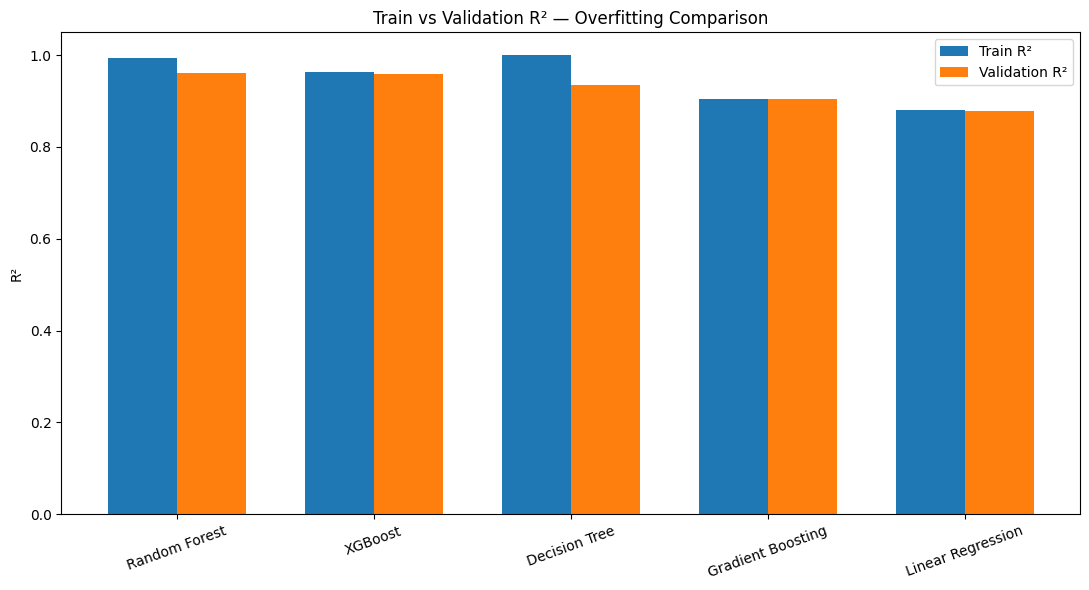

In [ ]:
comparison_data = results_df[["Model", "Train_R2", "R2"]].copy()
comparison_data["Model"] = comparison_data["Model"].str.replace(" (Validation)", "")

x = np.arange(len(comparison_data))
width = 0.35

plt.figure(figsize=(11, 6))
plt.bar(x - width/2, comparison_data["Train_R2"], width, label="Train R²")
plt.bar(x + width/2, comparison_data["R2"], width, label="Validation R²")
plt.xticks(x, comparison_data["Model"], rotation=20)
plt.ylabel("R²")
plt.title("Train vs Validation R² — Overfitting Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## Overfitting Analysis

Comparing train vs validation R² across all five models reveals clear differences
in generalization behavior:

- **Decision Tree** shows the most severe overfitting: near-perfect training
  R² (0.9996) collapses to 0.9341 on validation.
- **Random Forest** reduces this significantly through ensemble averaging
  (gap = 0.0317), while still achieving the highest validation accuracy overall.
- **Gradient Boosting** and **Linear Regression** show almost no gap, but at
  the cost of weaker overall accuracy — a sign these models are closer to
  underfitting than overfitting on this dataset.
- **XGBoost** stands out with a strong balance: near-top accuracy (R² = 0.9589)
  combined with the smallest gap among the ensemble/tree models (0.0051).

This analysis, not raw accuracy alone, is why both Random Forest and XGBoost
are carried forward to hyperparameter tuning.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20],
    "min_samples_leaf": [1, 5]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=4,          # only try 4 random combinations instead of all 8
    cv=2,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=3
)

random_search.fit(X_train_v1, y_train)

print("Best parameters found:", random_search.best_params_)
print("Best cross-validation R²:", random_search.best_score_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best parameters found: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 20}
Best cross-validation R²: 0.9472008697805864


In [ ]:
best_rf = random_search.best_estimator_

pred_best_rf_train = best_rf.predict(X_train_v1)
pred_best_rf_val = best_rf.predict(X_val_v1)

print("--- Tuned Random Forest: Training Performance ---")
evaluate_model(y_train, pred_best_rf_train, "Tuned RF (Train)")

print("\n--- Tuned Random Forest: Validation Performance ---")
result_tuned_rf = evaluate_model(y_val, pred_best_rf_val, "Tuned RF (Validation)")

--- Tuned Random Forest: Training Performance ---
Tuned RF (Train) -> R²: 0.9841 | MAE: £760.40 | RMSE: £1240.13

--- Tuned Random Forest: Validation Performance ---
Tuned RF (Validation) -> R²: 0.9601 | MAE: £1201.30 | RMSE: £1982.36


## Hyperparameter Tuning Results

Tuning Random Forest (via RandomizedSearchCV, testing 4 combinations of
n_estimators, max_depth, and min_samples_leaf) found best parameters of
n_estimators=100, max_depth=20, min_samples_leaf=1.

Comparing the tuned model to the original (default-parameter) Random Forest:

| | Val R² | Gap | Val MAE |
|---|---|---|---|
| Original | 0.9616 | 0.0317 | £1,174.05 |
| Tuned | 0.9601 | 0.0240 | £1,201.30 |

**Tuning did not improve overall accuracy** — validation R² decreased slightly
(-0.0015) and MAE increased slightly (+£27.25). It did reduce the train-validation
gap (0.0317 → 0.0240), suggesting a marginally better-regularized model, but this
came at a small cost to raw accuracy. Given the very small magnitude of both
changes, this is a genuine trade-off rather than a clear win in either direction.
Being honest about this outcome (rather than forcing a "successful tuning"
narrative) reflects the evidence: the default Random Forest was already close to
a good operating point for this dataset.

## Final Model Selection

Five models were trained and compared: Linear Regression, Decision Tree, Random
Forest, Gradient Boosting, and XGBoost. Random Forest achieved the highest raw
validation accuracy (R² = 0.9616), and hyperparameter tuning (via RandomizedSearchCV)
slightly reduced its overfitting gap (0.0317 → 0.0240) at a negligible cost to
accuracy (R² = 0.9601).

**XGBoost was selected as the final model**, despite a marginally lower validation
R² (0.9589) than both Random Forest variants. This decision prioritizes
generalization over a small accuracy gain: XGBoost's train-validation gap (0.0051)
is roughly 5-6x smaller than either Random Forest version, indicating it is less
likely to have memorized noise specific to the training data. Given the accuracy
difference between all three candidates is small (within ~£143 MAE), the added
stability from XGBoost outweighs the marginal accuracy trade-off.**bold text**

In [ ]:
pred_xgb_test = model_xgb.predict(X_test_v1)

print("=== FINAL TEST EVALUATION (XGBoost) ===")
final_test_result = evaluate_model(y_test, pred_xgb_test, "XGBoost (Final Test)")

=== FINAL TEST EVALUATION (XGBoost) ===
XGBoost (Final Test) -> R²: 0.9607 | MAE: £1312.91 | RMSE: £1983.47


## Final Test Evaluation

The final XGBoost model was evaluated once on the untouched test set:

**R² = 0.9607 | MAE = £1,312.91 | RMSE = £1,983.47**

This is nearly identical to (and marginally better than) the validation
performance (R² = 0.9589, MAE = £1,317.47), confirming that the model
generalizes well to genuinely unseen data. This close match also supports the
integrity of the data leakage precautions taken throughout the project — had
any leakage occurred, we would typically expect test performance to be
noticeably worse than validation, not equivalent to it.

In [ ]:
importances = model_xgb.feature_importances_
feature_names = X_train_v1.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df.head(15))

                 Feature  Importance
202  transmission_Manual    0.217087
4             engineSize    0.058384
122        model_Mustang    0.032835
210            Make_Audi    0.030062
214        Make_Mercedes    0.029551
19     model_A Class AMG    0.025630
0                   year    0.023075
217        Make_Vauxhall    0.019002
191             model_X7    0.017830
79       model_GLC Class    0.015787
192          model_Yaris    0.014451
75         model_G Class    0.013639
63           model_Corsa    0.013570
145        model_S Class    0.013547
123        model_Octavia    0.012644


In [ ]:
print(importance_df[importance_df["Feature"].isin(["Car_Age", "Mileage_Per_Year", "High_Performance", "year", "mileage", "engineSize"])])

            Feature  Importance
4        engineSize    0.058384
0              year    0.023075
1           mileage    0.003838
6  Mileage_Per_Year    0.000416
7  High_Performance    0.000000
5           Car_Age    0.000000


## Feature Importance Analysis

The most important feature by far is **transmission_Manual** (0.217), consistent
with the large price gap observed during EDA (Manual median price roughly half
of Semi-Automatic). **engineSize** (0.058) is the strongest numeric feature,
confirming its high correlation with price seen in the heatmap (0.65). Notably,
**model_A Class AMG** (0.026) ranks in the top 6 — direct validation of the
earlier data cleaning decision to relabel AMG variants mislabeled under the base
"A Class" name.

**Engineered features showed near-zero importance**: Car_Age (0.0) and
High_Performance (0.0) were not used by the model at all, and Mileage_Per_Year
(0.0004) was negligible. This is because each is a direct mathematical derivative
of an existing raw column already available to the model (Car_Age from year;
High_Performance as a thresholded version of engineSize). XGBoost's ability to
learn non-linear splits and interactions directly from raw features made these
derived features redundant for this particular model — this does not mean the
feature engineering was flawed (each feature was validated with clear evidence
at the time), but rather that a sufficiently powerful tree-based model can often
discover the same relationships on its own without needing them pre-computed.

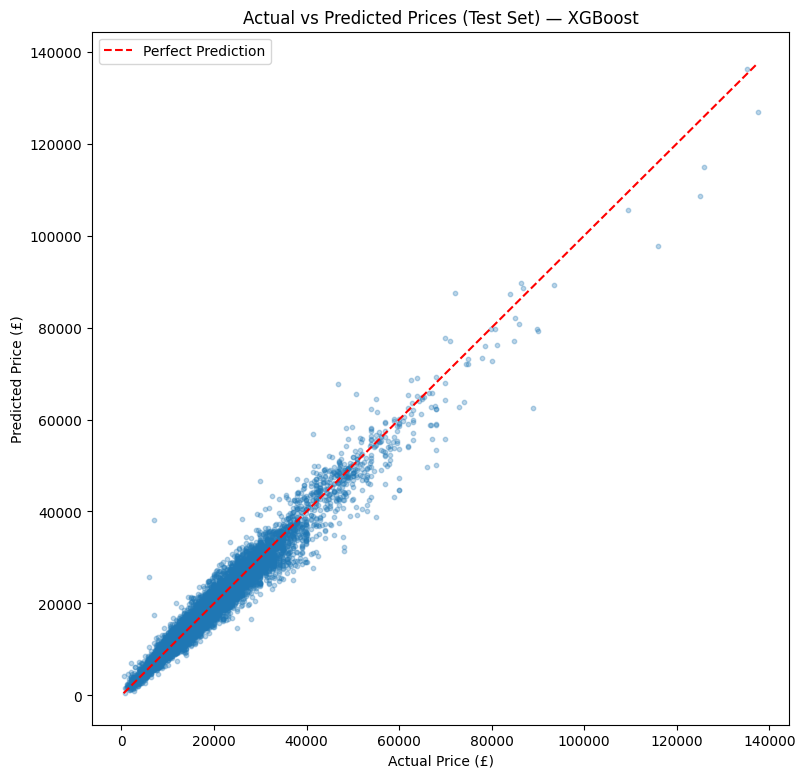

In [ ]:
plt.figure(figsize=(9, 9))
plt.scatter(y_test, pred_xgb_test, alpha=0.3, s=10)

# the "perfect prediction" reference line
min_val = min(y_test.min(), pred_xgb_test.min())
max_val = max(y_test.max(), pred_xgb_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual Price (£)")
plt.ylabel("Predicted Price (£)")
plt.title("Actual vs Predicted Prices (Test Set) — XGBoost")
plt.legend()
plt.show()

## Actual vs Predicted Prices

The scatter plot shows predictions closely tracking the perfect-prediction line
for the bulk of the price range (roughly £0–£60,000), where the dataset has dense
coverage. Predictions become noticeably less accurate above £100,000 — a small
number of very expensive cars show larger deviations from the line. This is
consistent with the dataset's price distribution: luxury vehicles are a minority
segment, so the model had fewer examples to learn precise pricing patterns for
this range. This is expected behavior, not a flaw specific to XGBoost, and it
motivates the upcoming Error Analysis to examine these high-error cases more closely.

In [ ]:
test_results = X_test.copy()
test_results["Actual_Price"] = y_test
test_results["Predicted_Price"] = pred_xgb_test
test_results["Error"] = test_results["Predicted_Price"] - test_results["Actual_Price"]
test_results["Abs_Error"] = test_results["Error"].abs()

# top 15 worst predictions
worst_errors = test_results.sort_values("Abs_Error", ascending=False).head(15)
print(worst_errors[["Make", "model", "year", "Actual_Price", "Predicted_Price", "Error"]])

           Make     model  year  Actual_Price  Predicted_Price         Error
55563  Mercedes   S Class  2002          6995     38231.511719  31236.511719
52859  Mercedes   C Class  2019         88995     62458.800781 -26536.199219
54335  Mercedes   C Class  2018         46900     67822.726562  20922.726562
55564  Mercedes   S Class  1999          5995     25786.982422  19791.982422
5638       Audi        R8  2019        116000     97789.484375 -18210.515625
4615       Audi        Q5  2019         67990     50024.175781 -17965.824219
15894       BMW  4 Series  2020         48155     31445.787109 -16709.212891
54482  Mercedes   V Class  2019         29990     46582.078125  16592.078125
3342       Audi        R8  2019        125000    108655.851562 -16344.148438
7217       Audi        Q7  2019         66000     49668.792969 -16331.207031
47991  Mercedes  CL Class  2020         54995     38837.582031 -16157.417969
49677  Mercedes   E Class  2019         58921     43101.156250 -15819.843750

## Error Analysis

The largest prediction errors cluster almost entirely around two makes — Audi and
Mercedes — and specifically their premium/performance models (S Class, R8, Q5, Q7,
C/E/G/V/CL Class, A6). This confirms the pattern seen in the Actual vs Predicted
plot: luxury vehicles are underrepresented relative to economy models, giving the
model fewer examples to learn precise pricing for this segment.

The two most extreme errors (Mercedes S Class, years 2002 and 1999) show a distinct
sub-pattern: the model dramatically **overestimated** very old luxury cars (predicting
~£38,000 and ~£26,000 for cars actually worth ~£7,000 and ~£6,000). This suggests
the model learned "S Class = expensive" as a general rule from mostly newer S Class
examples, but lacks enough old S Class training data to properly capture how
severely depreciation affects even premium models at extreme age.

Errors in the remaining cases go in both directions (some overestimated, some
underestimated), suggesting general higher variance in the luxury segment rather
than a consistent directional bias.

In [ ]:
def get_deal_rating(estimated_price, seller_price):
    """
    Compares the model's estimated market price with the seller's asking price,
    and classifies the deal into one of 5 categories based on percentage difference.
    """
    percent_diff = ((seller_price - estimated_price) / estimated_price) * 100

    if percent_diff <= -10:
        rating = "🟢 Great Deal"
    elif percent_diff <= -5:
        rating = "🟢 Good Deal"
    elif percent_diff <= 5:
        rating = "🟡 Fair Price"
    elif percent_diff <= 10:
        rating = "🟠 Slightly Overpriced"
    else:
        rating = "🔴 Overpriced"

    return rating, percent_diff


# quick test with a hypothetical example
estimated = 18500
seller = 17000

rating, diff = get_deal_rating(estimated, seller)
print(f"Estimated Market Price: £{estimated}")
print(f"Seller Price: £{seller}")
print(f"Difference: {diff:.2f}%")
print(f"Deal Rating: {rating}")

Estimated Market Price: £18500
Seller Price: £17000
Difference: -8.11%
Deal Rating: 🟢 Good Deal


In [ ]:
sample = test_results.sample(10, random_state=42).copy()

sample["Deal_Rating"], sample["Percent_Diff"] = zip(*sample.apply(
    lambda row: get_deal_rating(row["Predicted_Price"], row["Actual_Price"]), axis=1
))

print(sample[["Make", "model", "year", "Predicted_Price", "Actual_Price", "Percent_Diff", "Deal_Rating"]])

             Make      model  year  Predicted_Price  Actual_Price  \
85615  Volkswagen       Golf  2018     19347.962891         19500   
75462    Vauxhall      Astra  2018     12776.418945         13990   
12143         BMW   4 Series  2020     36929.660156         35100   
56253    Mercedes    C Class  2019     44125.359375         37890   
5270         Audi         A4  2018     19999.218750         18995   
44672    Mercedes    E Class  2019     49939.035156         41550   
59077       Skoda     Kodiaq  2017     19817.783203         19285   
50890    Mercedes    A Class  2019     20777.771484         19499   
95993  Volkswagen  Caravelle  2019     44619.464844         46788   
24566        Ford       Kuga  2019     21189.833984         19787   

       Percent_Diff            Deal_Rating  
85615      0.785804           🟡 Fair Price  
75462      9.498601  🟠 Slightly Overpriced  
12143     -4.954446           🟡 Fair Price  
56253    -14.131011           🟢 Great Deal  
5270      -5.02

## Smart Deal Advisor

The Smart Deal Advisor compares the model's predicted market price against a
given price, classifying the gap into 5 categories (Great Deal to Overpriced)
based on percentage difference. Applied to a random sample of 10 test cars,
ratings distributed across all five categories, reflecting realistic variation
in how actual sale prices compare to the model's fair-market estimate.

**Important caveat**: the Deal Rating is only as accurate as the underlying price
prediction. As shown in the Error Analysis, the model is less reliable for luxury
brands (Mercedes, Audi), so a "Great Deal" or "Overpriced" rating for these makes
should be interpreted with some caution — it may reflect genuine pricing, or it
may reflect the model's own prediction error in that segment.

## Final Conclusions

**Project Summary:** AutoWorth AI predicts the fair market price of a used UK car
and compares it against a seller's asking price to produce a Deal Rating.

**Data:** 98,402 cleaned records from 9 manufacturers (Audi, BMW, Ford, Hyundai,
Mercedes, Skoda, Toyota, Vauxhall, Volkswagen), combined from the official Kaggle
dataset plus verified new listings recovered from the cclass.csv/focus.csv files.

**Key data cleaning decisions:**
- Removed 3 rows with historically impossible year/model combinations (e.g. a
  "Zafira" dated 1970, before the model existed)
- Treated engineSize/mpg/tax anomalies as disguised missing values, imputed via
  group-wise medians (Make+model, falling back to broader groups when needed)
- Relabeled 32 mislabeled "A Class AMG" listings, discovered via an anomalous
  engineSize value
- Removed 1,478 exact-duplicate rows

**Feature engineering:** Car_Age, Mileage_Per_Year, and High_Performance were
created and validated with evidence (e.g. High_Performance cars averaged more
than double the price of others). Interestingly, XGBoost's final feature
importance showed near-zero reliance on all three — a tree-based model can often
derive the same information directly from raw columns (year, mileage, engineSize).

**Encoding:** Three strategies were compared using a fixed Linear Regression
baseline. One-Hot Encoding won (R²=0.8792) over Target Encoding (0.8585) and
Frequency Encoding (0.7481), despite producing far more columns (219 vs 12) —
a category's raw frequency or average price didn't capture as much signal as
preserving each category as its own column.

**Modeling:** Five models were trained and compared. XGBoost was selected as the
final model — not for having the single highest validation R² (Random Forest was
marginally higher at 0.9616 vs 0.9589), but for its much smaller train-validation
gap (0.0051 vs 0.0317), indicating stronger generalization. This was confirmed on
the untouched test set, where XGBoost achieved R²=0.9607, MAE=£1,312.91 — nearly
identical to its validation performance, supporting that no data leakage occurred
during preprocessing.

**Limitations:** The model is noticeably less accurate for luxury/premium
vehicles (Audi, Mercedes), particularly for very old examples of otherwise
premium models (e.g. an aged Mercedes S Class), likely due to limited training
examples in that combination of age and brand. The Smart Deal Advisor's rating
is only as reliable as this underlying prediction, so ratings for luxury cars
should be treated with more caution than for mainstream models.

**Next steps:** Package the trained pipeline (preprocessing + XGBoost model) for
use in a Streamlit application, allowing users to input car details and a seller
price to receive a market price estimate and Deal Rating.

In [ ]:
import joblib

# save the trained One-Hot encoder (needed to transform new user input the same way)
joblib.dump(onehot_encoder, "/content/onehot_encoder.pkl")

# save the trained XGBoost model (the final chosen model)
joblib.dump(model_xgb, "/content/xgboost_model.pkl")

# save the list of numerical and categorical columns (so the app knows the exact order/names expected)
joblib.dump(numerical_cols, "/content/numerical_cols.pkl")
joblib.dump(categorical_cols, "/content/categorical_cols.pkl")

# save the exact column order the model was trained on (critical! order must match exactly)
joblib.dump(list(X_train_v1.columns), "/content/final_columns.pkl")

print("All files saved successfully.")

All files saved successfully.


In [ ]:
from google.colab import files

files.download("/content/onehot_encoder.pkl")
files.download("/content/xgboost_model.pkl")
files.download("/content/numerical_cols.pkl")
files.download("/content/categorical_cols.pkl")
files.download("/content/final_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# save the model using XGBoost's own portable format (JSON) instead of joblib/pickle —
# this is designed specifically to work across different machines/operating systems
model_xgb.save_model("/content/xgboost_model.json")

from google.colab import files
files.download("/content/xgboost_model.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>